<class 'pandas.DataFrame'>
RangeIndex: 24999 entries, 0 to 24998
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    24999 non-null  str    
 1   customer_id             24999 non-null  int64  
 2   product_category        24999 non-null  int64  
 3   payment_method          24999 non-null  str    
 4   value [USD]             24999 non-null  float64
 5   time_on_site [Minutes]  24999 non-null  float64
 6   clicks_in_site          24999 non-null  int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 1.7 MB
None
       customer_id  product_category  value [USD]  time_on_site [Minutes]  \
count     24999.00          24999.00     24999.00                24999.00   
mean      35047.13            507.92       203.25                   73.13   
std       14448.79              4.29       208.02                  150.98   
min       10000.00            501.00         0.00      

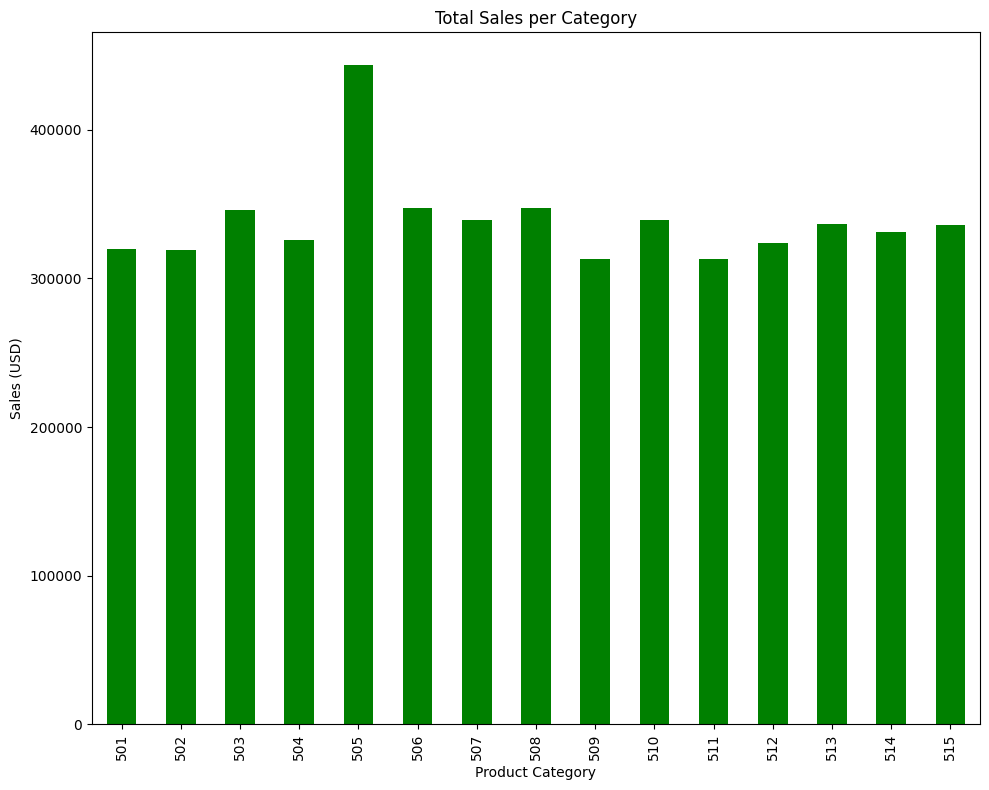

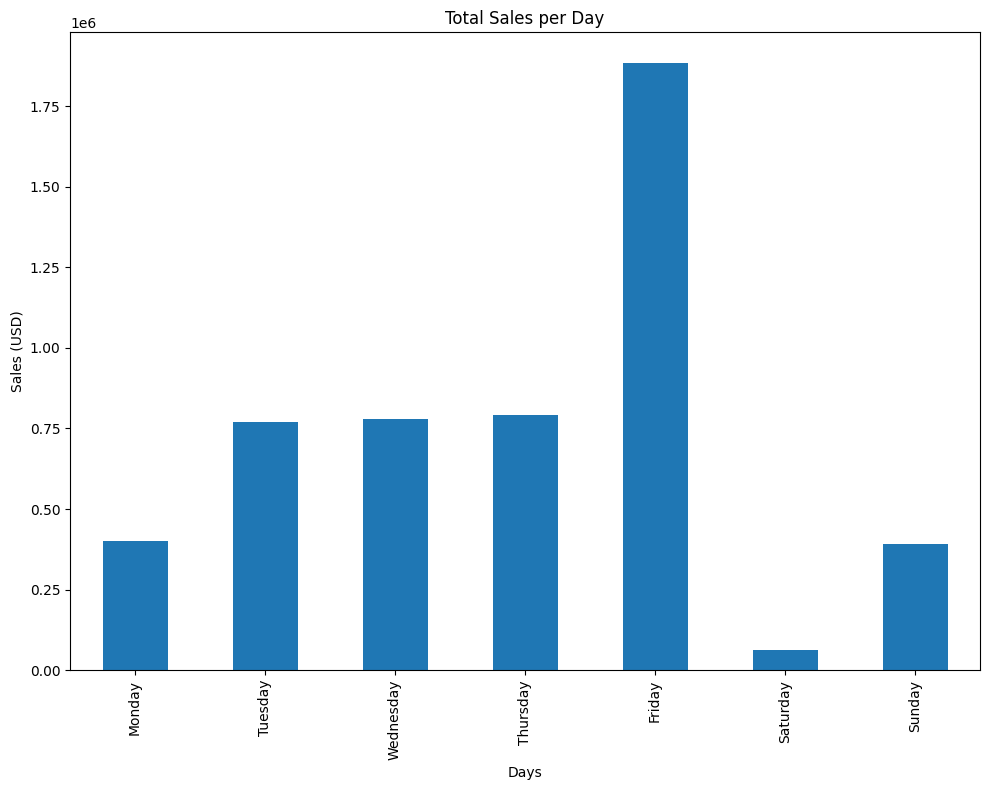

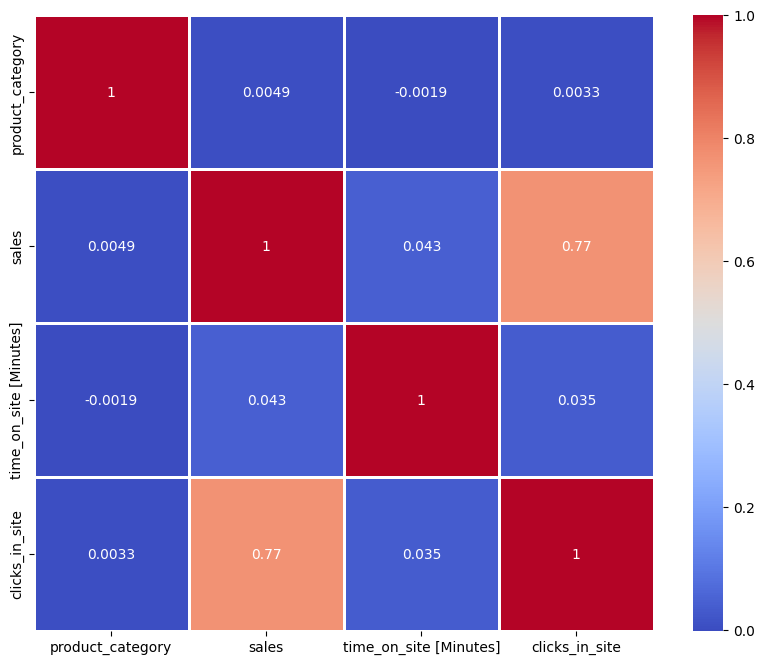

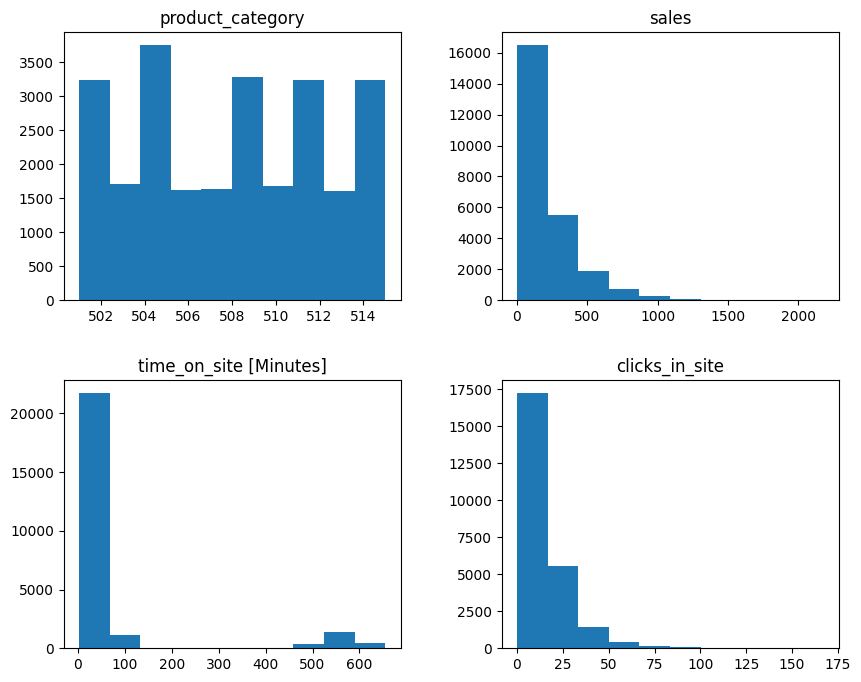

Minimum value in every features:
product_category          6.42 %
sales                      0.0 %
time_on_site [Minutes]    0.04 %
clicks_in_site            0.86 %
dtype: str


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

# Load data
df = pd.read_csv('purchase_data.csv')
print(df.info())
print(df.describe().round(2))
print(df.tail())
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
print(df.tail())

# Rename column
df = df.drop(columns='customer_id')
df = df.rename(columns={'value [USD]': 'sales'})


# Extract day name
df['day'] = df['date'].dt.day_name()

# Sales per category per day
df.groupby('product_category')['sales'].sum().plot(kind='bar', figsize=(10,8), grid=False, colormap='ocean')
plt.title('Total Sales per Category')
plt.ylabel('Sales (USD)')
plt.xlabel('Product Category')
plt.tight_layout()
plt.show()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df.groupby('day')['sales'].sum().reindex(day_order).plot(kind='bar', figsize=(10, 8), grid=False)
plt.title('Total Sales per Day')
plt.ylabel('Sales (USD)')
plt.xlabel('Days')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
df = df.drop(['date'], axis=1)
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', linewidths=2)
plt.show()

df.hist(bins=10, grid=False, figsize=(10,8))
plt.show()

# Count minimum value in every features
df_num = df.select_dtypes(include='number')
minimum = df_num.eq(df_num.min()).sum()
percentage = (minimum / df.shape[0] * 100).round(2)
print('Minimum value in every features:')
print(percentage.astype(str) + ' %')

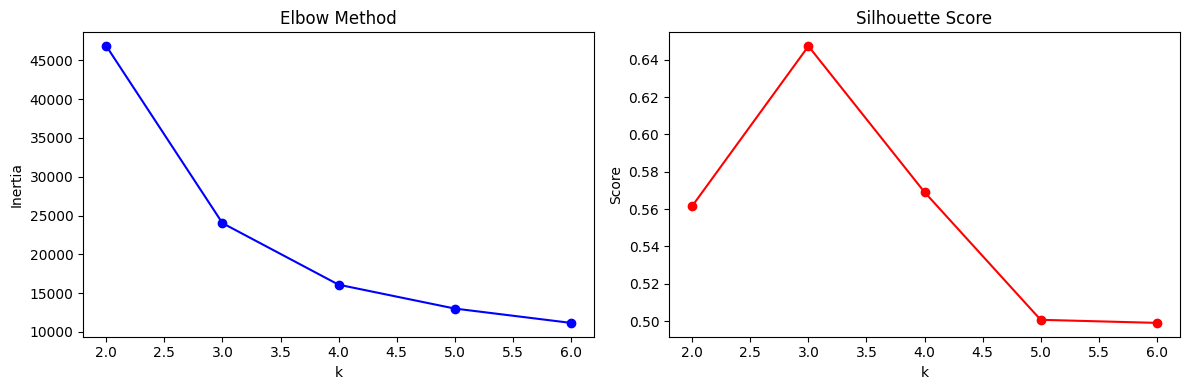

In [9]:

# Prepare features
features = ['sales', 'time_on_site [Minutes]', 'clicks_in_site']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal k
inertia, sil_scores = [], []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertia, 'bo-')
ax1.set(title='Elbow Method', xlabel='k', ylabel='Inertia')

ax2.plot(k_range, sil_scores, 'ro-')
ax2.set(title='Silhouette Score', xlabel='k', ylabel='Score')

plt.tight_layout()
plt.show()



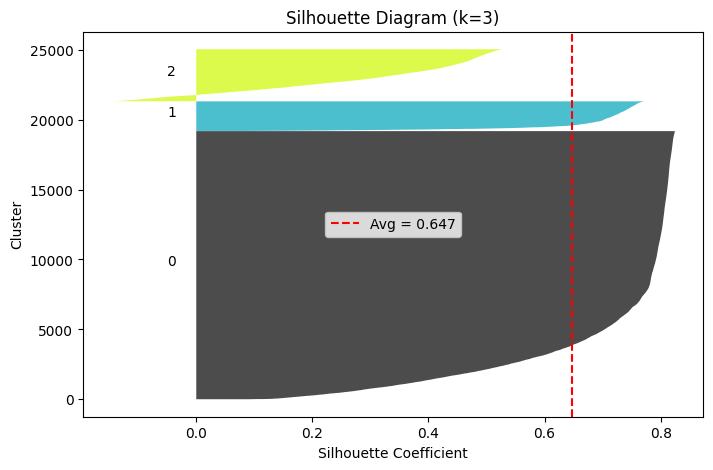


Cluster Profile (k=3):
|           |   sales |   time_on_site [Minutes] |   clicks_in_site |
|:----------|--------:|-------------------------:|-----------------:|
| Cluster 0 |  135.21 |                    23.86 |            11.72 |
| Cluster 1 |  174.43 |                   559.21 |            14.31 |
| Cluster 2 |  570.46 |                    50.32 |            39.31 | 



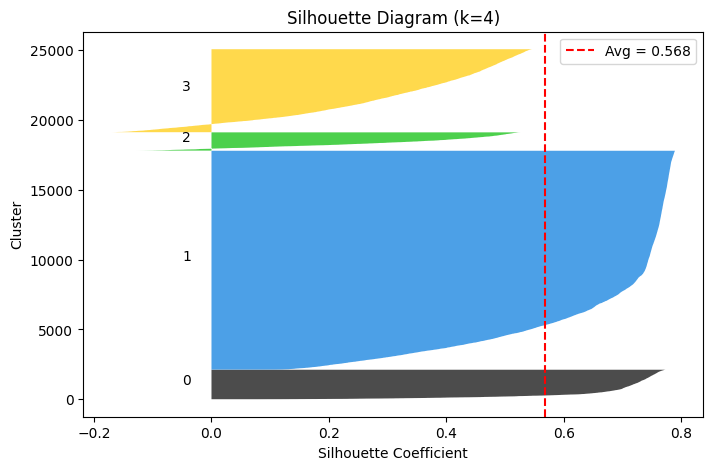


Cluster Profile (k=4):
|           |   sales |   time_on_site [Minutes] |   clicks_in_site |
|:----------|--------:|-------------------------:|-----------------:|
| Cluster 0 |  173.06 |                   559.1  |            14.17 |
| Cluster 1 |   97.42 |                    21.97 |             9.95 |
| Cluster 2 |  761.2  |                    72.69 |            57.25 |
| Cluster 3 |  370.24 |                    35.35 |            23.7  | 

Model Evaluation
|    |   K |   Silhouette (↑) |   Davies-Bouldin (↓) |   Calinski-Harabasz (↑) |   Inertia (↓) |
|---:|----:|-----------------:|---------------------:|------------------------:|--------------:|
|  1 |   3 |           0.6494 |               0.6554 |                 26538.5 |       24011.2 |
|  2 |   4 |           0.561  |               0.696  |                 30541.4 |       16074.1 |


In [10]:
# Try best k we found
results = []

for k in [3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=100)
    df['cluster'] = model.fit_predict(X_scaled)

    # Silhouette Diagram
    sil_vals = silhouette_samples(X_scaled, df['cluster'])
    avg_sil  = silhouette_score(X_scaled, df['cluster'], sample_size=5000)

    plt.figure(figsize=(8, 5))
    y_lower = 10
    for i in range(k):
        vals    = sorted(sil_vals[df['cluster'] == i])
        y_upper = y_lower + len(vals)
        color   = cm.nipy_spectral(i / k)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, alpha=0.7)
        plt.text(-0.05, y_lower + 0.5 * len(vals), str(i))
        y_lower = y_upper + 10

    plt.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg = {avg_sil:.3f}')
    plt.title(f'Silhouette Diagram (k={k})')
    plt.xlabel('Silhouette Coefficient')
    plt.ylabel('Cluster')
    plt.legend()
    plt.show()

    # Cluster profile
    profile = df.groupby('cluster')[features].mean().round(2)
    profile.index = [f'Cluster {i}' for i in profile.index]
    print(f"\nCluster Profile (k={k}):")
    print(profile.to_markdown(), '\n')

    # Store metrics
    results.append({
        'K'                 : k,
        'Silhouette (↑)'    : round(silhouette_score(X_scaled, df['cluster']), 4),
        'Davies-Bouldin (↓)': round(davies_bouldin_score(X_scaled, df['cluster']), 4),
        'Calinski-Harabasz (↑)': round(calinski_harabasz_score(X_scaled, df['cluster']), 4),
        'Inertia (↓)'       : round(model.inertia_, 2),
    })

# Evaluation table
print("Model Evaluation")
print(pd.DataFrame(results, index=range(1, len(results)+1)).to_markdown())